# **Importing the dataset Twitter Tweets**

In [ ]:
import tensorflow as tf
import torch

# Check if TensorFlow can see the GPU
print("TensorFlow version:", tf.__version__)
if tf.test.gpu_device_name():
    print(f"TensorFlow is using the GPU: {tf.test.gpu_device_name()}")
else:
    print("TensorFlow is not using the GPU")

# Check if PyTorch can see the GPU
if torch.cuda.is_available():
    print(f"PyTorch is using the GPU: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch is not using the GPU")


TensorFlow version: 2.17.1
TensorFlow is not using the GPU
PyTorch is not using the GPU


In [ ]:
import torch

class MyModel(torch.nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        # Define your model layers here
        self.linear = torch.nn.Linear(3, 3)  # Example layer

    def forward(self, x):
        # Define the forward pass for your model
        return self.linear(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyModel().to(device) # Now MyModel is defined
tensor = torch.randn((3, 3)).to(device)

In [ ]:
## Importing dataset Twitter Tweets

import pandas as pd

# For uploaded files
file_path = '/content/TwitterTweetsSentimentTraining.csv' # Replace with the actual path
data = pd.read_csv(file_path, engine='python', on_bad_lines='skip', encoding='latin-1') # Try 'latin-1' encoding

# For files downloaded from a URL
data = pd.read_csv(file_path, engine='python', on_bad_lines='skip', encoding='latin-1')  # Adjust the filename if needed

# Assign column names
data.columns = ['Rating', 'Cust_ID', 'Date and Time', 'Query', 'Username', 'Review'] # Replace with meaningful names
# Display the first few rows of the dataset
print(data.head())


   Rating     Cust_ID                 Date and Time     Query       Username  \
0       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY  scotthamilton   
1       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY       mattycus   
2       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY        ElleCTF   
3       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY         Karoli   
4       0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY       joy_wolf   

                                              Review  
0  is upset that he can't update his Facebook by ...  
1  @Kenichan I dived many times for the ball. Man...  
2    my whole body feels itchy and like its on fire   
3  @nationwideclass no, it's not behaving at all....  
4                      @Kwesidei not the whole crew   


In [ ]:
## Preprocessing the data
#Inspect the data
# Inspect the dataset structure
print(data.info())

# View sample rows
print(data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038531 entries, 0 to 1038530
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Rating         1038531 non-null  int64 
 1   Cust_ID        1038531 non-null  int64 
 2   Date and Time  1038531 non-null  object
 3   Query          1038531 non-null  object
 4   Username       1038531 non-null  object
 5   Review         1038531 non-null  object
dtypes: int64(2), object(4)
memory usage: 47.5+ MB
None
   Rating     Cust_ID                 Date and Time     Query       Username  \
0       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY  scotthamilton   
1       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY       mattycus   
2       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY        ElleCTF   
3       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY         Karoli   
4       0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY       joy_

In [ ]:
## clean the text data
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK data (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Define a function to clean the text
def clean_text(text):
    if text is None:
        return " " #this was done because some of the reviews didnt have anything written hence the .lower() command cannot execute in the cell below.
    # Convert text to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Apply the cleaning function to the text column
data['cleaned_text'] = data['Review'].apply(clean_text)  # Replace 'text_column' with the name of your text column


In [ ]:
#import the necessary library
from nltk.stem import PorterStemmer

#create an instance of the PorterStemmer
stemmer = PorterStemmer()

#applying stemming to my tokens.
def stem_words(text):
    tokens = word_tokenize(text)
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(stemmed_tokens)


In [ ]:
#apply stemming function to dataset
data['Processed_Review'] = data['cleaned_text'].apply(stem_words)


# **Vectorization**

Text data needs to be converted into numerical data before it can be used for machine learning. One common method to do this is using TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF measures the importance of a word in a document relative to its occurrence in a set of documents.**bold text**

In [ ]:
#vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
#Tf-IDF is a way to find out words that are important in terms of frequency in a
#single document but not that frequent in the collection of documents as
#such a word can be used by the model to segregate documents and help in sentiment
#analysis.

#Term frequency and Inverse Document Frequency
#Initializing the TF-IDF vector
vectorizer = TfidfVectorizer(max_features=1000000)



In [ ]:
#Fit and transform the data
X = vectorizer.fit_transform(data['Processed_Review'])
#This method learns the vocabulary and idf from the training set and returns the term-document matrix.

# **Traning the data**


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming 'X_df' is your vectorized text data and 'y' is your target (sentiment labels)
# For example, y could be the sentiment (positive, negative, neutral) for each review
y = data['Rating']
# Splitting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (348007, 314359)
Testing data shape: (149146, 314359)


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming 'X_df' is your vectorized text data and 'y' is your target (sentiment labels)
# For example, y could be the sentiment (positive, negative, neutral) for each review
y = data['Rating']
# Splitting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (348007, 314359)
Testing data shape: (149146, 314359)


# **Class Imbalance Problem**

In [ ]:
import pandas as pd
from collections import Counter

# Assuming your dataset is in a CSV file
# Try 'latin-1' encoding
data = pd.read_csv("/content/TwitterTweetsSentimentTraining.csv", encoding='latin-1')  # Replace with your dataset file name

print(data['0'].value_counts())  # Replace 'label' with your column name for sentiment

0
4    800000
0    799999
Name: count, dtype: int64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_resampled, y_resampled = rus.fit_resample(X_vectorized, y)

print("Class distribution after undersampling:")
print(Counter(y_resampled))


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Class distribution after undersampling:
Counter({0: 799999, 4: 799999})


# **Training the model (Logistic regression)**

Since we're working on sentiment analysis, we'll use a classifier such as a Logistic Regression model, which is often effective for text classification tasks.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print(classification_report(y_test, y_pred))


Model Accuracy: 78.85%
              precision    recall  f1-score   support

           0       0.80      0.76      0.78     74701
           4       0.77      0.81      0.79     74445

    accuracy                           0.79    149146
   macro avg       0.79      0.79      0.79    149146
weighted avg       0.79      0.79      0.79    149146



# **Training the model (Multinomial Naive Bayes)**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.76      0.82      0.79    159494
           4       0.80      0.75      0.77    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000

[[130314  29180]
 [ 40927 119579]]


# **Graphs and Analysis**

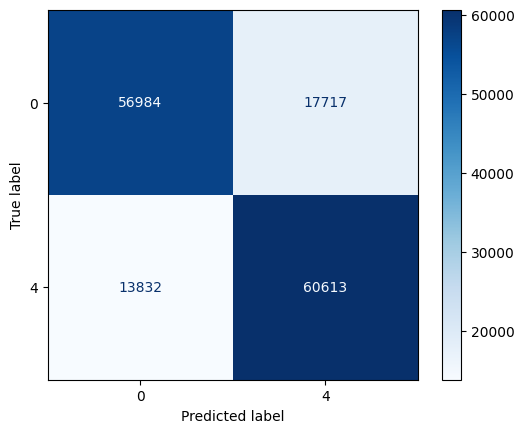

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
y_pred = model.predict(X_test)  # Replace with your prediction code
cm = confusion_matrix(y_test, y_pred, labels=[0, 4])  # Replace labels as needed

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 4])
disp.plot(cmap=plt.cm.Blues)
plt.show()


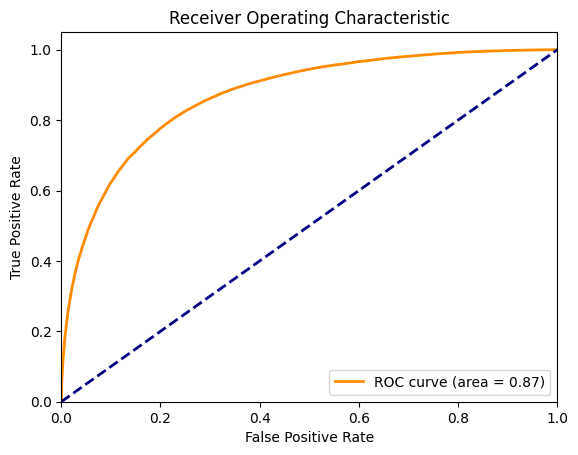

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compute ROC curve, specifying the positive label
fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label=4)  # Set pos_label to 4
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


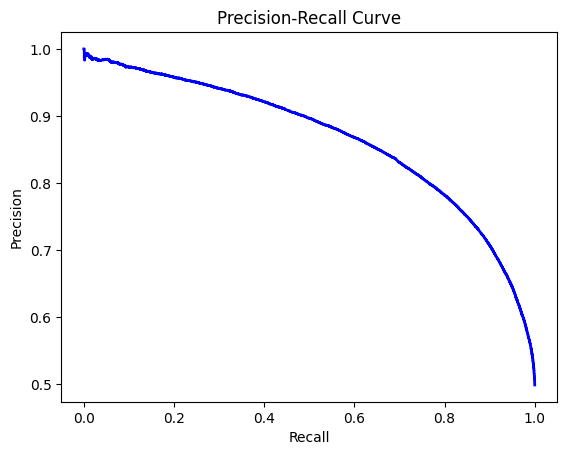

In [ ]:
from sklearn.metrics import precision_recall_curve

# Assuming 4 is the positive class
pos_label = 4

# Compute precision-recall curve, specifying the positive label
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba, pos_label=pos_label)

# Plot Precision-Recall curve
plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# **Testing it with new data**

In [ ]:
# Import necessary libraries
import numpy as np

# Function to preprocess user input
def preprocess_user_input(text):
    # Step 1: Clean the text
    cleaned_text = clean_text(text)

    # Step 2: Transform the cleaned text into vectorized form
    text_vector = vectorizer.transform([cleaned_text])

    return text_vector

# Function to predict sentiment
def predict_sentiment(text):
    # Preprocess the user input
    text_vector = preprocess_user_input(text)

    # Predict sentiment using the trained model
    prediction = model.predict(text_vector)

    # Interpret the prediction
    if prediction == 0:
        sentiment = "Negative"
    else:
        sentiment = "Positive"

    return sentiment

# Continuously take user input until 'end' is entered
while True:
    user_input = input("Enter a review (or type 'end' to quit): ")
    if user_input.lower() == 'end':
        print("Exiting...")
        break
    sentiment = predict_sentiment(user_input)
    print(f"The predicted sentiment is: {sentiment}\n")


Enter a review (or type 'end' to quit): this product is bad
The predicted sentiment is: Negative

Enter a review (or type 'end' to quit): exit
The predicted sentiment is: Positive

Enter a review (or type 'end' to quit): end
Exiting...


# **Improving Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type ('elasticnet' requires 'saga' solver, can be skipped for simplicity)
    'solver': ['liblinear'],  # Solver ('liblinear' supports both 'l1' and 'l2')
    'max_iter': [100, 200, 300]  # Maximum number of iterations
}

# Create a Logistic Regression model
model = LogisticRegression()

# Step 2: Choose a Tuning Method (Grid Search)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)

# Step 3: Fit the Model
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.2f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ..C=0.1, max_iter=100, penalty=l1, solver=liblinear; total time=   1.3s
[CV] END ..C=0.1, max_iter=100, penalty=l1, solver=liblinear; total time=   1.3s
[CV] END ..C=0.1, max_iter=100, penalty=l1, solver=liblinear; total time=   1.3s
[CV] END ..C=0.1, max_iter=100, penalty=l1, solver=liblinear; total time=   1.3s
[CV] END ..C=0.1, max_iter=100, penalty=l1, solver=liblinear; total time=   1.2s
[CV] END ..C=0.1, max_iter=100, penalty=l2, solver=liblinear; total time=   1.8s
[CV] END ..C=0.1, max_iter=100, penalty=l2, solver=liblinear; total time=   1.7s
[CV] END ..C=0.1, max_iter=100, penalty=l2, solver=liblinear; total time=   4.0s
[CV] END ..C=0.1, max_iter=100, penalty=l2, solver=liblinear; total time=   1.6s
[CV] END ..C=0.1, max_iter=100, penalty=l2, solver=liblinear; total time=   1.6s
[CV] END ..C=0.1, max_iter=200, penalty=l1, solver=liblinear; total time=   1.3s
[CV] END ..C=0.1, max_iter=200, penalty=l1, solv

In [ ]:
# Use the best model found by Grid Search
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")


Test Set Accuracy: 0.79


In [ ]:
# Import the necessary library
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model with the best parameters
best_model = LogisticRegression(C=1, max_iter=100, penalty='l2', solver='liblinear')

# Fit the model on the entire training dataset
best_model.fit(X_train, y_train)

# Evaluate the model on the test set
test_accuracy = best_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")


Test Accuracy: 0.79


In [ ]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, classification_report

# Predict the labels on the test set
y_pred = best_model.predict(X_test)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Generate classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


Confusion Matrix:
[[56983 17718]
 [13836 60609]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78     74701
           4       0.77      0.81      0.79     74445

    accuracy                           0.79    149146
   macro avg       0.79      0.79      0.79    149146
weighted avg       0.79      0.79      0.79    149146



# **Model and Vectorization with .pkl files download**

In [ ]:
import pickle

# Assuming `model` is your trained model and `vectorizer` is your vectorizer object
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))
